# CODE OVERVIEW

This code was developed by **Aritra Roy**, former *S.N. Bhatt Memorial Excellence Fellow (2024)* at the [International Centre for Theoretical Sciences (ICTS-TIFR), Bangalore](https://www.icts.res.in/news/results-icts-s-n-bhatt-memorial-excellence-fellowship-program-2024).

---

## Technical Specifications: 2D Pseudo-Spectral Navier-Stokes Solver

This numerical framework solves the 2D incompressible Navier-Stokes equations in the vorticity-streamfunction ($\omega$-$\psi$) formulation. The implementation relies on high-order spectral accuracy coupled with efficient physical-space evaluations.

### 1. Mathematical Formulation
The governing equation is the 2D advection-diffusion equation for vorticity:

$$\frac{\partial \omega}{\partial t} + \mathbf{u} \cdot \nabla \omega = \nu \nabla^2 \omega$$

Where:
*   $\omega = \nabla \times \mathbf{u} = -\nabla^2\psi$ is the scalar vorticity field.
*   $\psi$ is the streamfunction mapping out the velocity components: $u = \frac{\partial\psi}{\partial y}$, $v = -\frac{\partial\psi}{\partial x}$.
*   $\nu$ is the kinematic viscosity fluid parameter.

### 2. Computational Domain
*   **Geometry:** Doubly-periodic square domain $(x, y) \in [0, 2\pi) \times [0, 2\pi)$.
*   **Grid Point Setup:** Discretized using an equidistant grid generated via `endpoint=False`. This explicitly omits the $2\pi$ point to strictly prevent coordinate duplication in the Discrete Fourier Transform (DFT).

### 3. Pseudo-Spectral Strategy
The algorithm strategically transitions between Fourier space and physical space to ensure optimal computational complexity:
*   **Linear Operators:** Spatial derivatives ($\nabla$) and Laplacian inversions ($\nabla^{-2}$) are converted into local algebraic multiplications in Fourier space using discrete wavenumbers $k_x$ and $k_y$:
    
    $$\frac{\partial}{\partial x} \longrightarrow i k_x, \qquad \nabla^2 \longrightarrow -k^2 = -(k_x^2 + k_y^2)$$

*   **Nonlinear Terms:** The convective term $\mathbf{u} \cdot \nabla \omega = u \frac{\partial \omega}{\partial x} + v \frac{\partial \omega}{\partial y}$ is evaluated in **physical space** to avoid executing expensive $O(N^4)$ mathematical convolutions in frequency space.

### 4. 2/3 Dealiasing Rule (Orszag Filter)
Evaluating nonlinear terms via physical grid multiplication triggers high-frequency energy truncation errors (aliasing). To guarantee stability and clear out unresolvable grid modes, **Orszag’s 2/3 rule** is applied in Fourier space before evaluation:

$$\hat{\omega}(k_x, k_y) = 0 \quad \text{for } \sqrt{k_x^2 + k_y^2} > \frac{2}{3} \cdot k_{\text{max}} = \frac{N}{3}$$

### 5. Time Advancment
The resulting system forms a stiff, coupled set of ordinary differential equations (ODEs):

$$\frac{d\mathbf{\Omega}}{dt} = \text{RHS}(\mathbf{\Omega})$$

This vector field is integrated using adaptive time-stepping algorithms (via standard packages like `scipy.integrate.solve_ivp`), using a fixed visualization time stride ($d_s$) decoupled from the internal numerical timestep ($\Delta t$).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.fft import fft2, ifft2
from scipy.integrate import solve_ivp
from IPython.display import display, clear_output

In [2]:
# parameters for the simulation 
nu = 1e-4     #kinematic viscosity

# 2. COMPUTATIONAL DOMAIN & GRID GENERATION

The simulation is performed on a doubly-periodic square domain:

$$x \in [0,2\pi), \qquad y \in [0,2\pi)$$

Periodicity implies:

$$f(0,y)=f(2\pi,y)$$

$$f(x,0)=f(x,2\pi)$$

Such domains are ideal for Fourier spectral methods because Fourier basis functions are inherently periodic.

The argument `endpoint=False` in `np.linspace(0, 2*np.pi, N, endpoint=False)` generates the grid:

$$0, \quad \Delta x, \quad 2\Delta x, \quad \ldots, \quad 2\pi-\Delta x$$

This excludes the final point $2\pi$, since $f(0)=f(2\pi)$ in a periodic domain. 

Including both points would duplicate a physical location and lead to inconsistencies in the FFT representation.


In [3]:
Lx = 2 * np.pi
Ly = 2 * np.pi

Nx = 1024                      # Number of grid points in x-direction
Ny = 1024                      # Number of grid points in y-direction

dx = Lx / Nx                  # Uniform grid spacing in x
dy = Ly / Ny                  # Uniform grid spacing in y

# Construct 1D periodic coordinate arrays
x = np.linspace(0, Lx, Nx, endpoint=False)
y = np.linspace(0, Ly, Ny, endpoint=False)

# 2D physical mesh
X, Y = np.meshgrid(x, y, indexing='xy')

# Total degrees of freedom
Nxy = Nx * Ny #Total number of unknowns solve_ivp expects the state vector


# 3. FOURIER WAVENUMBERS & DEALIASING FILTER

Spectral methods represent the solution as a sum of Fourier modes:

$$\exp(i(k_x x + k_y y))$$

Therefore, derivatives become algebraic operations:

$$\frac{\partial}{\partial x} \longrightarrow i \cdot k_x$$

$$\frac{\partial}{\partial y} \longrightarrow i \cdot k_y$$

This is one of the major advantages of spectral methods: **spatial derivatives become extremely accurate**.

The function `np.fft.fftfreq()` generates the discrete Fourier frequencies corresponding to the standard FFT ordering:

$$0, \ 1, \ 2, \ \ldots, \ +k, \ -k, \ \ldots, \ -2, \ -1$$

The grid spacing scaling factor:

$$d = \frac{\Delta x}{2\pi}$$

converts these default frequencies into physical Fourier wavenumbers appropriate for a domain length of $2\pi$.


In [4]:
kx = np.fft.fftfreq(Nx, d=dx / (2 * np.pi))
ky = np.fft.fftfreq(Ny, d=dy / (2 * np.pi))

# 2/3 DEALIASING RULE (ORSZAG FILTER)

Nonlinear terms are computed in **physical space**:

$$u\omega_x + v\omega_y$$

Multiplication in physical space corresponds to **convolution** in Fourier space. This convolution can generate modes beyond the highest resolvable Fourier mode.

Those unresolved modes "fold back" into the lower frequencies and create nonphysical energy contamination called **aliasing error**.

To suppress this, Orszag's 2/3 rule removes all Fourier modes where:

$$|k| > \frac{N}{3}$$

before nonlinear evaluation. 


In [5]:
kx[np.abs(kx) > (Nx / 3)] = 0.0
ky[np.abs(ky) > (Ny / 3)] = 0.0

# Construct full 2D spectral grids
Kx, Ky = np.meshgrid(kx, ky, indexing='xy')

# Spectral Laplacian operator:
#
#       ∇² -> -(kx² + ky²)
#
K2 = Kx**2 + Ky**2

# 4. PRECOMPUTED SPECTRAL OPERATORS

In 2D incompressible flow, vorticity ($\omega$) is related to the streamfunction ($\psi$) by the Poisson equation:

$$\omega = -\nabla^2\psi$$

Once the streamfunction $\psi$ is known, the velocity components are recovered via:

$$u = \frac{\partial\psi}{\partial y}, \qquad v = -\frac{\partial\psi}{\partial x}$$

In Fourier space, the Laplacian operator becomes algebraic ($\nabla^2 \longrightarrow -k^2$), allowing us to solve the Poisson equation directly:

$$\hat{\psi} = \frac{\hat{\omega}}{k^2}$$

Therefore, velocity reconstruction becomes extremely efficient. 

The zero Fourier mode ($k^2 = 0$) corresponds to the spatial mean component (DC offset) and cannot be inverted. We therefore set its inverse value to zero explicitly to avoid a division-by-zero error.


In [6]:
K2inv = np.zeros_like(K2)

# Only invert nonzero spectral modes
K2inv[K2 != 0] = 1.0 / K2[K2 != 0]

# Precompute derivative multipliers:
#
#       Dx = i*kx/k²
#       Dy = i*ky/k²
#
# These operators directly reconstruct velocity from vorticity.
#
Dx = 1j * Kx * K2inv
Dy = 1j * Ky * K2inv

# 5. INITIAL CONDITION GENERATION

We initialize the flow field directly in **Fourier space** instead of physical space.

### Why initialize in Fourier space?

Injecting energy into only **low Fourier modes** automatically creates a smooth, large-scale flow structure. 

If random noise were directly assigned in physical space, the initial field would contain high-frequency oscillations. This can cause severe numerical instability or artificial noise at the start of the simulation.

By exciting only a few low-frequency modes:

$$\hat{\omega}(k_x, k_y) \neq 0 \quad \text{for } |k| \le k_{\text{max}}$$

the resulting Inverse Fast Fourier Transform (IFFT) produces a perfectly smooth initial vorticity field ($\omega$) in physical space.


In [7]:
np.random.seed(1)     # Ensures reproducible simulations


def InitCond():

    # Allocate empty Fourier-space vorticity field
    Om_hat = np.zeros((Ny, Nx), dtype=complex)

    # Inject random complex amplitudes into selected large-scale modes
    #
    # These modes determine the initial flow structures.
    #
    Om_hat[0, 4] = np.random.randn() + 1j * np.random.randn()
    Om_hat[1, 1] = np.random.randn() + 1j * np.random.randn()
    Om_hat[3, 0] = np.random.randn() + 1j * np.random.randn()

    # Convert back to physical space
    #
    # ifft2() returns complex values due to numerical roundoff.
    # Physically the field is real, hence we take only the real part.
    #
    Om = np.real(ifft2(Om_hat))

    # Normalize field amplitude so that:
    #
    #       max|ω| = 1
    #
    # This prevents extremely large or extremely small initial magnitudes.
    #
    Om /= np.max(np.abs(Om))

    return Om

# 6. RIGHT-HAND SIDE OF NAVIER-STOKES EQUATION

This routine computes the time derivative of vorticity:

$$\frac{\partial \omega}{\partial t}$$

for the ODE integrator. The solver treats the partial differential equation (PDE) as a **very large coupled system of Ordinary Differential Equations (ODEs)**:

$$\frac{d\mathbf{\Omega}}{dt} = \text{RHS}(\mathbf{\Omega})$$

where $\mathbf{\Omega}$ is the flattened vorticity field vector.

### Governing Equation (Advection-Diffusion Form)
The evaluated 2D incompressible Navier-Stokes equation in vorticity form is:

$$\frac{\partial \omega}{\partial t} = \underbrace{-\mathbf{u} \cdot \nabla \omega}_{\text{Advection}} + \underbrace{\nu \nabla^2 \omega}_{\text{Diffusion}}$$

Expanding this into component form for our 2D Cartesian grid yields:

$$\frac{\partial \omega}{\partial t} = -\left( u \frac{\partial \omega}{\partial x} + v \frac{\partial \omega}{\partial y} \right) + \nu \left( \frac{\partial^2 \omega}{\partial x^2} + \frac{\partial^2 \omega}{\partial y^2} \right)$$

### Pseudo-Spectral Implementation Strategy
To evaluate this equation efficiently, the implementation follows a **pseudo-spectral strategy**:

*   **Spectral Space Evaluation:** Spatial derivatives ($\nabla \omega$ and $\nabla^2 \omega$) are computed with extreme accuracy using Fourier multipliers.
*   **Physical Space Evaluation:** The nonlinear advection products ($u \omega_x$ and $v \omega_y$) are multiplied point-by-point in physical space to bypass expensive Fourier convolutions.

This hybrid approach perfectly combines **spectral accuracy** with **optimal computational efficiency**.


In [8]:
def RHS(t, Om_vec):

    # -------------------------------------------------------------------------
    # Reshape flattened vector back into 2D physical field
    # -------------------------------------------------------------------------
    Om = Om_vec.reshape((Ny, Nx))

    # Fourier transform of vorticity
    Om_hat = fft2(Om)

    # -------------------------------------------------------------------------
    # Compute vorticity gradients spectrally
    #
    # Spectral differentiation:
    #
    #       ∂ω/∂x -> i*kx*ω̂
    #       ∂ω/∂y -> i*ky*ω̂
    #
    # Inverse FFT converts derivatives back to physical space.
    # -------------------------------------------------------------------------
    Omx = np.real(ifft2(1j * Kx * Om_hat))
    Omy = np.real(ifft2(1j * Ky * Om_hat))

    # -------------------------------------------------------------------------
    # Velocity reconstruction from vorticity
    #
    # Using:
    #
    #       u =  ∂ψ/∂y
    #       v = -∂ψ/∂x
    #
    # with:
    #
    #       ψ̂ = ω̂/k²
    # -------------------------------------------------------------------------
    u = np.real(ifft2(Dy * Om_hat))
    v = np.real(ifft2(-Dx * Om_hat))

    # -------------------------------------------------------------------------
    # Diffusion term
    #
    # Since:
    #
    #       ∇² -> -k²
    #
    # then:
    #
    #       ν∇²ω -> -ν*k²*ω̂
    # -------------------------------------------------------------------------
    diffusion = np.real(ifft2(-nu * K2 * Om_hat))

    # -------------------------------------------------------------------------
    # Nonlinear advection term
    #
    #       uωx + vωy
    #
    # This is computed in physical space because multiplication is easier
    # there than evaluating convolutions directly in Fourier space.
    # -------------------------------------------------------------------------
    advection = u * Omx + v * Omy

    # Final RHS:
    #
    #       ∂ω/∂t = diffusion - advection
    #
    rhs = diffusion - advection

    # solve_ivp requires a flattened 1D vector
    return rhs.flatten()

# 7. TIME-INTEGRATION PARAMETERS

The integration duration and data tracking are controlled by two distinct parameters:

*   $T_f$: **Final simulation time** (total physical duration of the run).
*   $d_s$: **Visualization update interval** (stride for saving/displaying states).

> ### Key Distinction
> The routine `scipy.integrate.solve_ivp` internally utilizes **adaptive time-stepping** based on error tolerances. 
> Therefore, $d_s$ is **not** the numerical timestep ($\Delta t$). It only specifies **how frequently the solution is captured or visualized**.


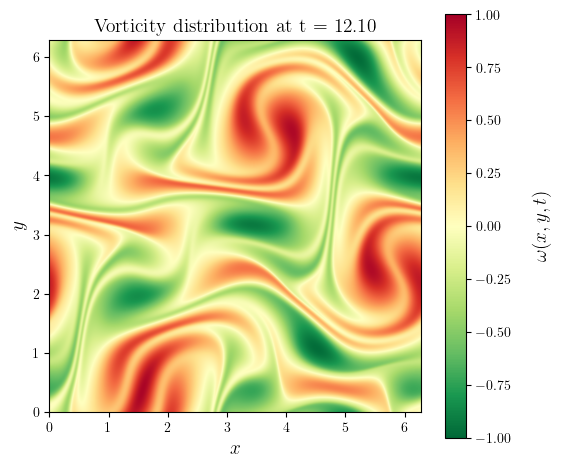

In [9]:
t = 0.0
Tf = 12.0
ds = 0.1
# =============================================================================
# 8. INITIALIZE FLOW FIELD
# =============================================================================
Om = InitCond()

# Flatten field into 1D vector for solve_ivp
Om_vec = Om.flatten()

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"]
})

fig, ax = plt.subplots(figsize=(6, 5.5))

im = ax.imshow(
    Om,
    extent=[0, Lx, 0, Ly],
    origin='lower',
    cmap='RdYlGn_r',  # <-- Replaces 'jet' with reversed Red-Yellow-Green
    vmin=-1,
    vmax=1
)

# Axis labels styled in LaTeX math mode
ax.set_xlabel(r'$x$', fontsize=14, usetex=True)
ax.set_ylabel(r'$y$', fontsize=14, usetex=True)

# Colorbar configuration with a vertical LaTeX label
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r'$\omega(x,y,t)$', rotation=90, fontsize=14, usetex=True, labelpad=15)

# Dynamic title object utilizing mixed text and math LaTeX blocks
title = ax.set_title(rf'\textrm{{Vorticity distribution at }} t = {t:.2f}', fontsize=14, usetex=True)



while t < Tf:

    # -------------------------------------------------------------------------
    # Integrate from current time to next visualization instant
    # -------------------------------------------------------------------------
    sol = solve_ivp(
        RHS,
        [t, t + ds],
        Om_vec,
        method='RK45',
        rtol=1e-8,
        atol=1e-8
    )

    # -------------------------------------------------------------------------
    # Extract final solution state
    # -------------------------------------------------------------------------
    Om_vec = sol.y[:, -1]

    # Convert back to 2D field
    Om = Om_vec.reshape((Ny, Nx))

    # Advance physical time
    t += ds

    # -------------------------------------------------------------------------
    # Update displayed image
    # -------------------------------------------------------------------------
    im.set_data(Om)

    # Update title
    title.set_text(f"Vorticity distribution at t = {t:.2f}")

    # -------------------------------------------------------------------------
    # Refresh notebook frame
    # -------------------------------------------------------------------------
    clear_output(wait=True)
    display(fig)

plt.close()